# Assignment No. 2

Name: yash vyas<br>
Roll No.: IT-2K24-97

## Question 4: Numerical Quadrature

### Method 4.1: Newton-Cotes Formula (Simpson 1/3 Rule)

**Assumptions**

- f(x) is continuous on [a, b].
- n is even for Simpson 1/3 rule.

**Algorithm (Simpson 1/3 Rule)**

1. Start
2. Read function f(x), limits a, b, and even n
3. Compute h = (b - a) / n
4. total = f(a) + f(b)
5. For i = 1 to n - 1
6.    If i is odd, add 4 * f(a + i*h) to total
7.    Else add 2 * f(a + i*h) to total
8. End For
9. Approximate integral = (h / 3) * total
10. Print result
11. Stop
12. End

,i,x_i,coef,f(x_i),term
0,0,0.0,1,0.00,0.00
1,1,0.1,4,0.01,0.04
2,2,0.2,2,0.04,0.08
3,3,0.3,4,0.09,0.36
4,4,0.4,2,0.16,0.32
5,5,0.5,4,0.25,1.00
6,6,0.6,2,0.36,0.72
7,7,0.7,4,0.49,1.96
8,8,0.8,2,0.64,1.28
9,9,0.9,4,0.81,3.24


Approximate integral: 0.3333333333333333


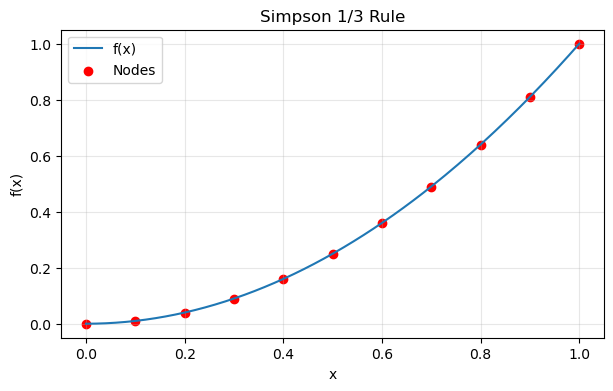

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def simpson_one_third_rule(func, a, b, n):
    if n % 2 != 0:
        raise ValueError("n must be even for Simpson 1/3 rule.")

    h = (b - a) / n
    total = func(a) + func(b)
    rows = [
        {"i": 0, "x_i": a, "coef": 1, "f(x_i)": func(a), "term": func(a)}
    ]

    for i in range(1, n):
        x_i = a + i * h
        coefficient = 4 if i % 2 == 1 else 2
        fx = func(x_i)
        total += coefficient * fx
        rows.append({"i": i, "x_i": x_i, "coef": coefficient, "f(x_i)": fx, "term": coefficient * fx})

    rows.append({"i": n, "x_i": b, "coef": 1, "f(x_i)": func(b), "term": func(b)})
    table = pd.DataFrame(rows)
    return (h / 3) * total, table


def f_quad(x):
    return x**2


approx_integral, table = simpson_one_third_rule(f_quad, 0.0, 1.0, 10)
display(table)
print("Approximate integral:", approx_integral)

xs = np.linspace(0.0, 1.0, 200)
ys = [f_quad(x) for x in xs]
x_nodes = table["x_i"]
y_nodes = [f_quad(x) for x in x_nodes]

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label="f(x)")
plt.scatter(x_nodes, y_nodes, color="red", label="Nodes")
plt.title("Simpson 1/3 Rule")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Time Complexity: O(n)

Space Complexity: O(1)

### Method 4.2: Gauss Quadrature Formula (2-Point)

**Assumptions**

- f(x) is continuous on [a, b].
- The 2-point Gauss-Legendre rule is used.

**Algorithm (2-Point Gauss Quadrature)**

1. Start
2. Read function f(x), limits a, b
3. Set t1 = -1/sqrt(3), t2 = 1/sqrt(3)
4. Map nodes to [a, b] to get x1, x2
5. Approximate integral = (b - a)/2 * (f(x1) + f(x2))
6. Print result
7. Stop
8. End

,i,t,x_i,w,f(x_i),w*f(x_i)
0,1,-0.57735,0.211325,0.5,0.044658,0.022329
1,2,0.57735,0.788675,0.5,0.622008,0.311004


Approximate integral: 0.3333333333333333


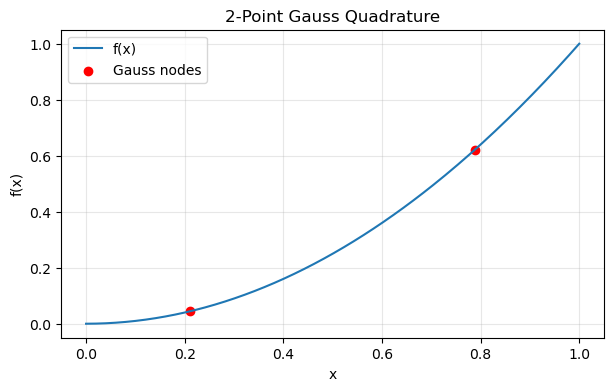

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def gauss_quadrature_two_point(func, a, b):
    t1 = -1.0 / (3.0 ** 0.5)
    t2 = 1.0 / (3.0 ** 0.5)

    x1 = (a + b) / 2.0 + (b - a) * t1 / 2.0
    x2 = (a + b) / 2.0 + (b - a) * t2 / 2.0

    w = (b - a) / 2.0
    approx = w * (func(x1) + func(x2))
    table = pd.DataFrame([
        {"i": 1, "t": t1, "x_i": x1, "w": w, "f(x_i)": func(x1), "w*f(x_i)": w * func(x1)},
        {"i": 2, "t": t2, "x_i": x2, "w": w, "f(x_i)": func(x2), "w*f(x_i)": w * func(x2)},
    ])
    return approx, table


def f_quad(x):
    return x**2


approx_integral, table = gauss_quadrature_two_point(f_quad, 0.0, 1.0)
display(table)
print("Approximate integral:", approx_integral)

xs = np.linspace(0.0, 1.0, 200)
ys = [f_quad(x) for x in xs]
x_nodes = table["x_i"]
y_nodes = [f_quad(x) for x in x_nodes]

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label="f(x)")
plt.scatter(x_nodes, y_nodes, color="red", label="Gauss nodes")
plt.title("2-Point Gauss Quadrature")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Time Complexity: O(1)

Space Complexity: O(1)